<a href="https://colab.research.google.com/github/QasimNiazi86/StockPredictionLSTM/blob/main/Tutorial15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


/tmp/ipykernel_19568/2242888889.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GOOGL', start='2010-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open     Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL      GOOGL
Date                                                             
2010-01-04  15.555865  15.624369  15.493568  15.560829   78169752
2010-01-05  15.487360  15.582917  15.426552  15.566536  120067812
2010-01-06  15.096946  15.533776  15.049788  15.533776  158988852
2010-01-07  14.745495  15.140132  14.709507  15.125239  256315428
2010-01-08  14.942071  14.972598  14.621645  14.693375  188783028
X_train shape: (2942, 60, 1), y_train shape: (2942, 1)

Starting training...
Epoch [1/10], Loss: 0.0263
Epoch [2/10], Loss: 0.0003
Epoch [3/10], Loss: 0.0002
Epoch [4/10], Loss: 0.0001
Epoch [5/10], Loss: 0.0001
Epoch [6/10], Loss: 0.0001
Epoch [7/10], Loss: 0.0001
Epoch [8/10], Loss: 0.0001
Epoch [9/10], Loss: 0.0001
Epoch [10/10], Loss: 0.0001


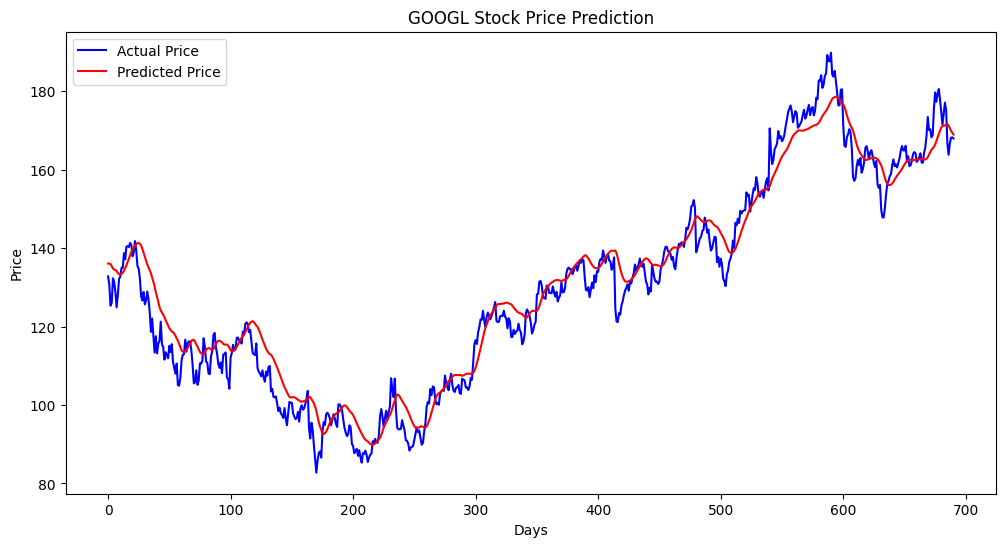


Predicted next day's price for GOOGL: $168.58


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1. Configuration & Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Fetch Google Stock Data
print("Downloading GOOGL stock data...")
df = yf.download('GOOGL', start='2010-01-01', end='2024-12-01')
print(df.head())

# Focus on the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

# 3. Preprocess Data [cite: 349-359]
# Scale data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split into training (80%) and testing (20%) data
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# 4. Create Sequences [cite: 360-370]
def create_sequences(data_array, seq_length):
    X, y = [], []
    for i in range(len(data_array) - seq_length):
        X.append(data_array[i:i + seq_length])
        y.append(data_array[i + seq_length])
    return np.array(X), np.array(y)

sequence_length = 60 # Use the past 60 days to predict the next day's price [cite: 367]
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')

# Convert Numpy arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device) # Keep test on device for evaluation
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader for batching
batch_size = 32 # [cite: 383]
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 5. Build the LSTM Model [cite: 372-378]
class StockPredictionLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(StockPredictionLSTM, self).__init__()
        # By setting num_layers=2, we mimic the two stacked LSTMs from Keras
        # (where the first layer has return_sequences=True)
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        # Two dense layers [cite: 377-378]
        self.fc1 = nn.Linear(hidden_size, 25)
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        # lstm_out contains all hidden states, _ contains the final state
        lstm_out, _ = self.lstm(x)

        # Extract the output of the LAST time step (equivalent to return_sequences=False) [cite: 376]
        last_time_step_out = lstm_out[:, -1, :]

        # Pass through dense layers
        out = self.fc1(last_time_step_out)
        out = self.fc2(out)
        return out

model = StockPredictionLSTM().to(device)

# Compile the model [cite: 379-380]
criterion = nn.MSELoss() # mean_squared_error
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Train the Model [cite: 382-383]
epochs = 10 # [cite: 383]
print("\nStarting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

# 7. Evaluate and Visualize Predictions [cite: 384-398]
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predictions = predictions.cpu().numpy()

# Convert back to original scale [cite: 388]
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test) # [cite: 390]

# Plot predictions and actual prices [cite: 391-398]
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual Price', color='blue')
plt.plot(predictions_rescaled, label='Predicted Price', color='red')
plt.title('GOOGL Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

# 8. Predict Future Prices [cite: 399-406]
# Use the last sequence from the scaled data [cite: 401]
last_sequence = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)
last_sequence_tensor = torch.tensor(last_sequence, dtype=torch.float32).to(device)

# Predict the next day's price [cite: 402-404]
model.eval()
with torch.no_grad():
    next_day_prediction = model(last_sequence_tensor)
    next_day_prediction = next_day_prediction.cpu().numpy()

# Inverse transform [cite: 405]
next_day_price = scaler.inverse_transform(next_day_prediction)

print(f"\nPredicted next day's price for GOOGL: ${next_day_price[0][0]:.2f}") # [cite: 406]